# Regressor Analysis

This notebook is reorganized into clear stages: environment setup, model/data loading, activation probing, regression evaluation, and interpretability checks.

## 1) Setup

In [1]:
import sys
from datetime import datetime
from pathlib import Path
import importlib

import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError("Cannot find project root containing 'src' directory.")


PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.preparation import prepare_data
from src.train.config_setup import load_and_prepare_model
from src.utils.mask_utils import get_non_pad_mask
from src.utils.metrics import regression_metrics
from src.utils.utils import _to_np_datetime64_seconds, set_seed
import src.data.event_loader as loader
import src.utils.viz_analysis as analysis
import src.utils.interpretability as interp

set_seed(0)
np.random.seed(0)
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
NOTEBOOK_NAME = 'regressor_analysis'
FIG_DIR = PROJECT_ROOT / 'notebooks' / 'figs' / NOTEBOOK_NAME
FIG_BATCH_DIR = FIG_DIR / 'batch'
FIG_DIR.mkdir(parents=True, exist_ok=True)
FIG_BATCH_DIR.mkdir(parents=True, exist_ok=True)

data_start = [1970, 1, 1, 0, 0, 0]
t0_np = _to_np_datetime64_seconds(datetime(*data_start))

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DEVICE: {DEVICE}')

PROJECT_ROOT: /root/autodl-tmp/em_eqf
DEVICE: cuda:0


## 2) Load Model and Data

In [2]:
CHECKPOINT_DIR = PROJECT_ROOT / 'experiments/reg_mixer_attnpl_a/runs/reg_ab_reg_seed_1'
CHECKPOINT_PATH = CHECKPOINT_DIR / 'last_model_1.pth'
USE_TORCH_COMPILE = True
BATCH_SIZE = 32
BATCH_OFFSET_FROM_END = 3


model, args = load_and_prepare_model(
    checkpoint_path=CHECKPOINT_PATH,
    device=DEVICE,
    compile=USE_TORCH_COMPILE,
)
args.batch_size = BATCH_SIZE

base_dir = PROJECT_ROOT / 'data' / args.dataset
df, train_loader, val_loader, test_loader, catalog_ds = prepare_data(base_dir=str(base_dir), args=args)
data_loader = loader.get_dataloader(
    catalog_ds,
    batch_size=args.batch_size,
    shuffle=False,
    task_type=args.task_type,
)


def collect_device_batches(loader_obj, device: torch.device):
    xs, ys = [], []
    for x_batch, y_batch in loader_obj:
        xs.append(x_batch.to(device))
        ys.append(y_batch.to(device))
    return xs, ys


xs, ys = collect_device_batches(test_loader, DEVICE)
x_eval = xs[-BATCH_OFFSET_FROM_END].clone()
y_eval = ys[-BATCH_OFFSET_FROM_END]

print(f'Loaded checkpoint: {CHECKPOINT_PATH}')
print(f'Dataset: {args.dataset} | test batches: {len(xs)} | selected batch shape: {tuple(x_eval.shape)}')

Loaded checkpoint: /root/autodl-tmp/em_eqf/experiments/reg_mixer_attnpl_a/runs/reg_ab_reg_seed_1/last_model_1.pth
Dataset: ChuanDian | test batches: 6 | selected batch shape: (32, 307, 7)


## 3) Activation Probing

/root/miniconda3/lib/python3.12/site-packages/torch/_inductor/compile_fx.py:167: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


mean: -0.014704180881381035
std : 0.898801863193512
min : -5.900115013122559
max : 4.960175514221191


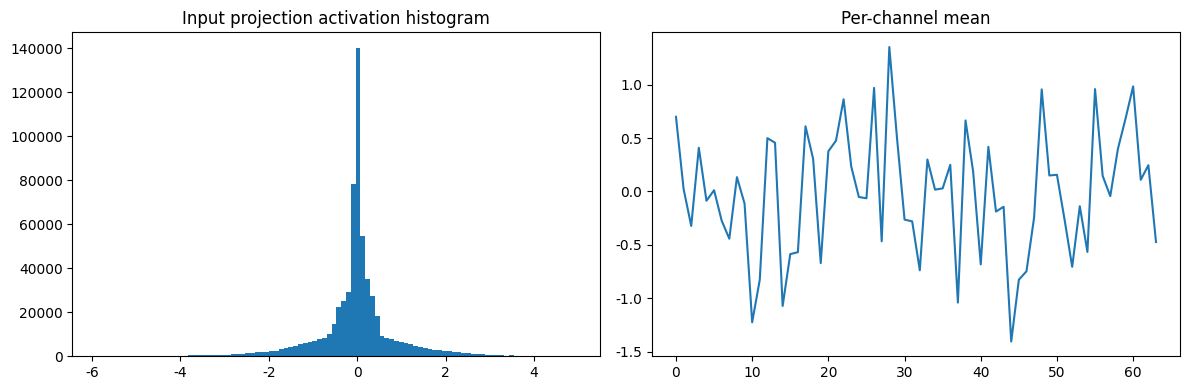

In [3]:
def inject_magnitude_ramp(x: torch.Tensor, mag_channel: int = 2, min_mag: float = 3.0, max_mag: float = 7.5):
    x_probe = x.clone()
    ramp = torch.linspace(min_mag, max_mag, steps=x_probe.size(1), device=x_probe.device)
    x_probe[:, :, mag_channel] = ramp.unsqueeze(0).expand(x_probe.size(0), -1)
    return x_probe


def capture_input_projection(model: torch.nn.Module, x: torch.Tensor) -> torch.Tensor:
    captured = []

    def _hook(_module, _inp, out):
        if isinstance(out, tuple):
            out = out[0]
        captured.append(out.detach().cpu())

    hook_handle = model.base_model.encoder.input_proj.register_forward_hook(_hook)
    try:
        with torch.no_grad():
            _ = model(x)
    finally:
        hook_handle.remove()

    if not captured:
        raise RuntimeError('No activations were captured from encoder.input_proj.')
    return captured[0]


def plot_activation_summary(h: torch.Tensor):
    print('mean:', float(h.mean()))
    print('std :', float(h.std()))
    print('min :', float(h.min()))
    print('max :', float(h.max()))

    channel_means = h.mean(dim=(0, 1)).numpy()
    h_flat = h.reshape(-1).numpy()

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.hist(h_flat, bins=100)
    plt.title('Input projection activation histogram')

    plt.subplot(1, 2, 2)
    plt.plot(channel_means)
    plt.title('Per-channel mean')
    plt.tight_layout()
    plt.show()


x_probe = inject_magnitude_ramp(x_eval, mag_channel=2, min_mag=3.0, max_mag=7.5)
h = capture_input_projection(model, x_probe)
plot_activation_summary(h)

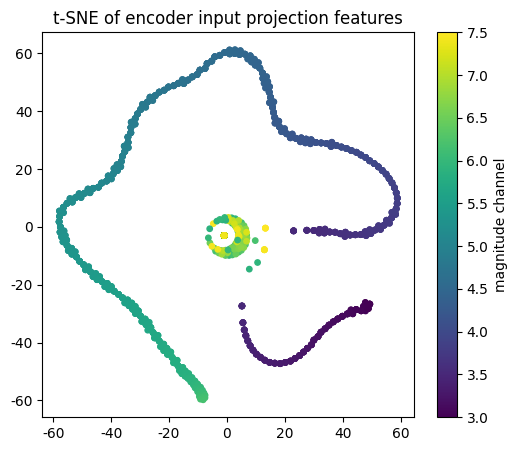

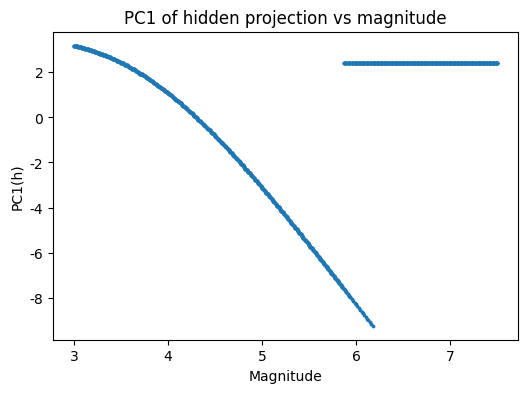

In [4]:
# Dimensional diagnostics: t-SNE and PCA
import src.utils.interpretability as interp
to_numpy = getattr(interp, 'to_numpy', None)
if to_numpy is None:
    def to_numpy(arr):
        if hasattr(arr, 'detach') and callable(arr.detach):
            arr = arr.detach()
            if hasattr(arr, 'cpu') and callable(arr.cpu):
                arr = arr.cpu()
            if hasattr(arr, 'numpy') and callable(arr.numpy):
                return arr.numpy()
        if hasattr(arr, 'to_numpy') and callable(arr.to_numpy):
            return arr.to_numpy()
        return np.asarray(arr)

h_np = to_numpy(h[:5]).reshape(-1, h.shape[-1])
labels = to_numpy(x_probe[:5, :, 2]).reshape(-1)

X_emb = TSNE(n_components=2, random_state=42).fit_transform(h_np)
plt.figure(figsize=(6, 5))
sc = plt.scatter(X_emb[:, 0], X_emb[:, 1], c=labels, cmap='viridis', s=15)
plt.colorbar(sc, label='magnitude channel')
plt.title('t-SNE of encoder input projection features')
plt.show()

pc1 = PCA(n_components=1).fit_transform(h_np)[:, 0]
plt.figure(figsize=(6, 4))
plt.scatter(labels, pc1, s=3)
plt.xlabel('Magnitude')
plt.ylabel('PC1(h)')
plt.title('PC1 of hidden projection vs magnitude')
plt.show()


## 4) Regression Evaluation

W0518 13:32:04.505000 412357 site-packages/torch/_dynamo/convert_frame.py:844] [4/8] torch._dynamo hit config.cache_size_limit (8)
W0518 13:32:04.505000 412357 site-packages/torch/_dynamo/convert_frame.py:844] [4/8]    function: 'forward' (/root/autodl-tmp/em_eqf/src/models/mamba/block.py:43)
W0518 13:32:04.505000 412357 site-packages/torch/_dynamo/convert_frame.py:844] [4/8]    last reason: 4/0: ___check_obj_id(L['residual'], 9667616)                     
W0518 13:32:04.505000 412357 site-packages/torch/_dynamo/convert_frame.py:844] [4/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W0518 13:32:04.505000 412357 site-packages/torch/_dynamo/convert_frame.py:844] [4/8] To diagnose recompilation issues, see https://pytorch.org/docs/main/torch.compiler_troubleshooting.html.


Validation metrics:


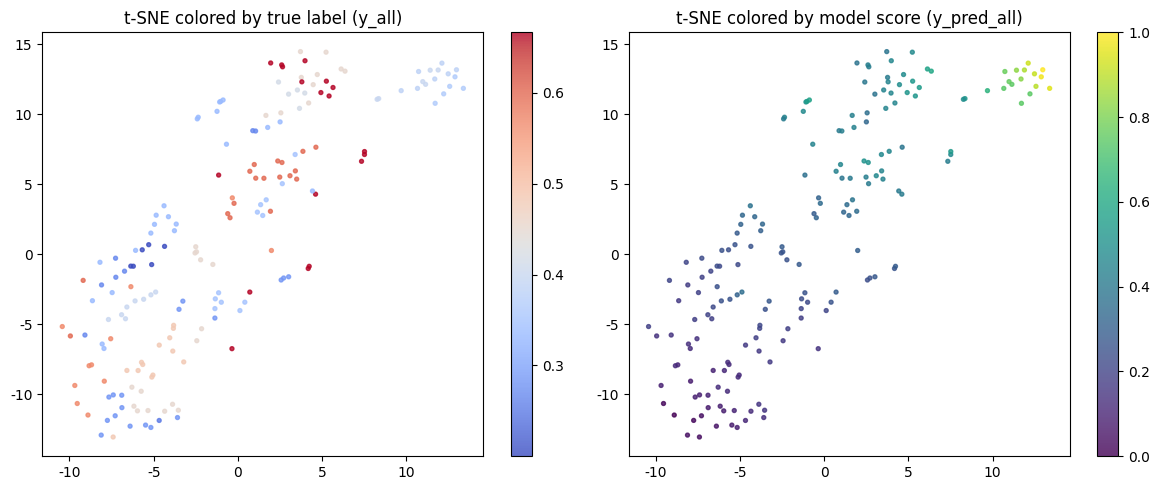

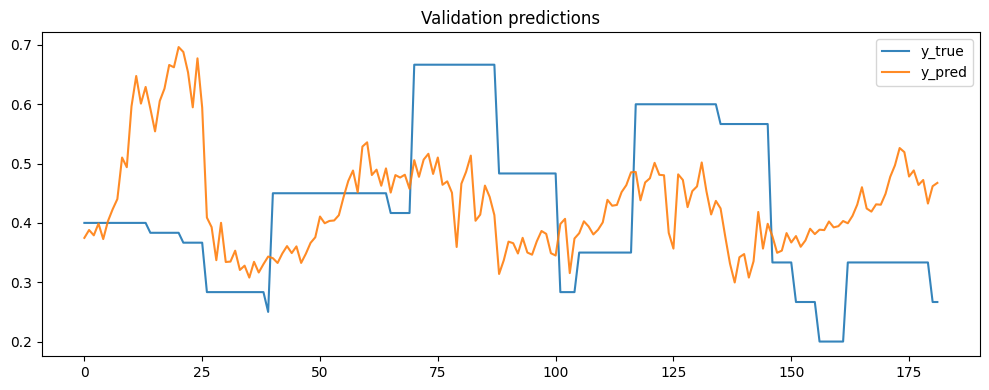

In [5]:
y_pred_val, y_val, X_val = analysis.predict_all(model, val_loader, DEVICE, return_X=True)

print('Validation metrics:')
regression_metrics(y_val, y_pred_val)

_X_scaled, _X_tsne, _y_score = analysis.tsne_scatter(X_val, y_val, y_pred_val)

plt.figure(figsize=(10, 4))
plt.plot(y_val, label='y_true', alpha=0.9)
plt.plot(y_pred_val, label='y_pred', alpha=0.9)
plt.title('Validation predictions')
plt.legend()
plt.tight_layout()
plt.show()

## 5) Interpretability

In [6]:
importlib.reload(interp)

IG_STEPS = 300
SAMPLE_IDX = 14

scores, labels = interp.compute_token_importance(
    model,
    x_eval,
    method='ig',
    n_steps=IG_STEPS,
    signed=True,
)

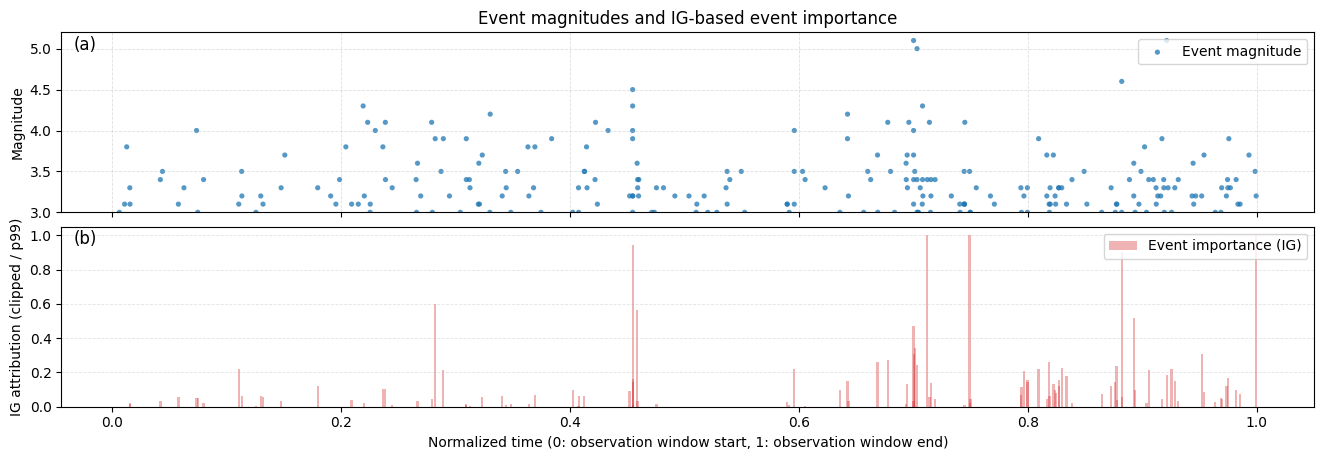

Top tokens by importance (index, score):
 1. idx=166 score=0.107332
 2. idx=243 score=0.091611
 3. idx=152 score=0.072226
 4. idx=84  score=0.065453
 5. idx=200 score=0.062694
 6. idx=43  score=0.041725
 7. idx=88  score=0.039031
 8. idx=202 score=0.036073
 9. idx=136 score=0.032638
10. idx=141 score=0.023606
11. idx=140 score=0.021236
12. idx=228 score=0.021176
13. idx=128 score=0.019025
14. idx=180 score=0.018127
15. idx=126 score=0.017914
16. idx=142 score=0.016671
17. idx=197 score=0.016273
18. idx=189 score=0.015683
19. idx=221 score=0.015414
20. idx=177 score=0.015223
Baseline prediction: 0.372891
Top-k deletion drops:
k= 1 drop=0.004011
k= 2 drop=0.027739
k= 5 drop=0.015388
k=10 drop=0.013273
Least-k deletion drops (sanity):
k= 1 drop=0.000000
k= 2 drop=0.000000
k= 5 drop=0.000000
k=10 drop=0.000000


In [7]:
mask = get_non_pad_mask(x_eval[:, :, 0]).squeeze(-1).cpu().numpy().astype(bool)
fig = interp.plot_event_magnitude_and_importance_clean(
    x_eval,
    scores,
    batch_idx=SAMPLE_IDX,
    time_channel=1,
    mag_channel=2,
    importance_norm='p99',
    savepath=str(FIG_DIR / 'reg_interp_nl.pdf'),
    mag_color='tab:blue',
    imp_color='tab:red',
    mask=mask,
    imp_ylim =None,
    height_ratios=(2, 2),
     panel_labels=('(a)', '(b)'),
)

valid_mask = (x_eval[SAMPLE_IDX].abs().sum(dim=-1) > 0)
ranks = interp.rank_tokens_numeric(
    token_scores=scores,
    sample_idx=SAMPLE_IDX,
    valid_mask=valid_mask,
    topn=20,
)

print('Top tokens by importance (index, score):')
for i, (idx, score) in enumerate(ranks['top'], 1):
    print(f'{i:>2}. idx={idx:<3} score={score:.6f}')

validation = interp.deletion_validation_numeric(
    model=model,
    x=x_eval,
    token_scores=scores,
    sample_idx=SAMPLE_IDX,
    topk_list=(1, 2, 5, 10),
    deletion_mode='zero',
    baseline_strategy='zeros',
    valid_mask=valid_mask,
    return_details=True,
)

print(f"Baseline prediction: {validation['baseline']:.6f}")
print('Top-k deletion drops:')
for row in validation['results']['topk']:
    print(f"k={row['k']:>2} drop={row['drop']:.6f}")

print('Least-k deletion drops (sanity):')
for row in validation['results']['leastk']:
    print(f"k={row['k']:>2} drop={row['drop']:.6f}")

## 6) Batch Interpretability Export

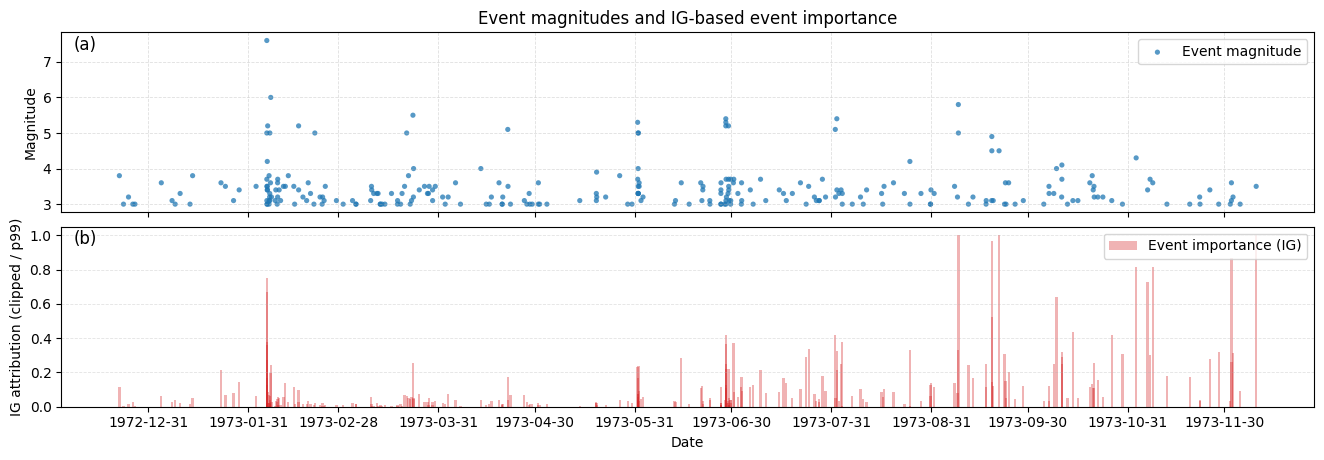

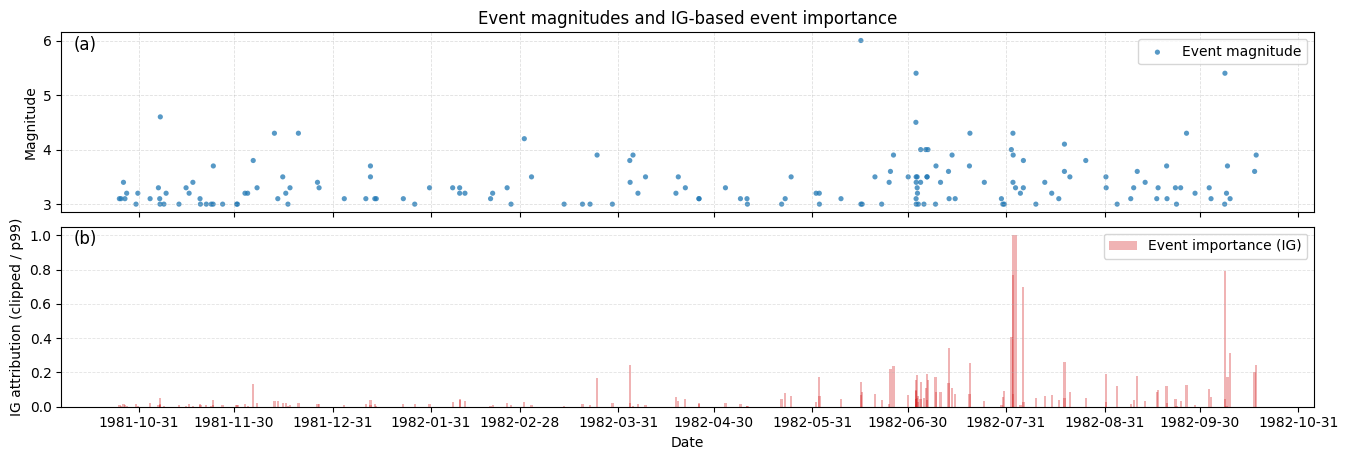

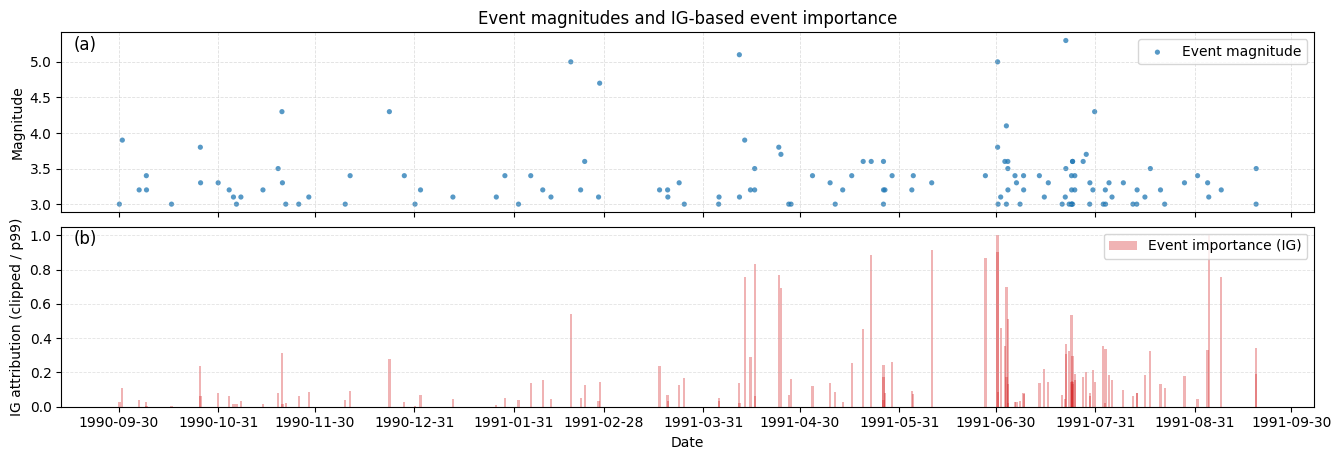

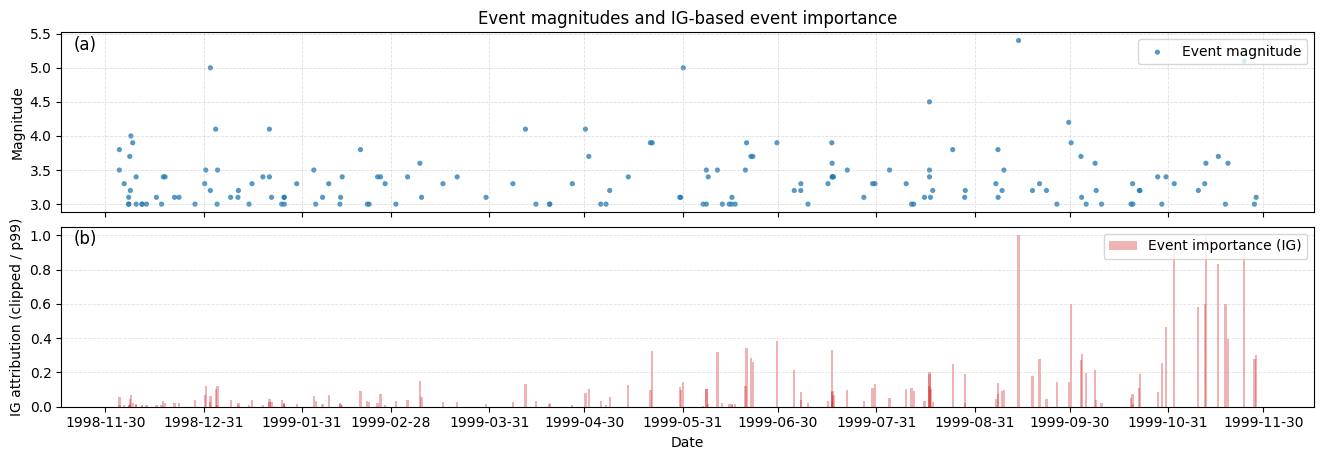

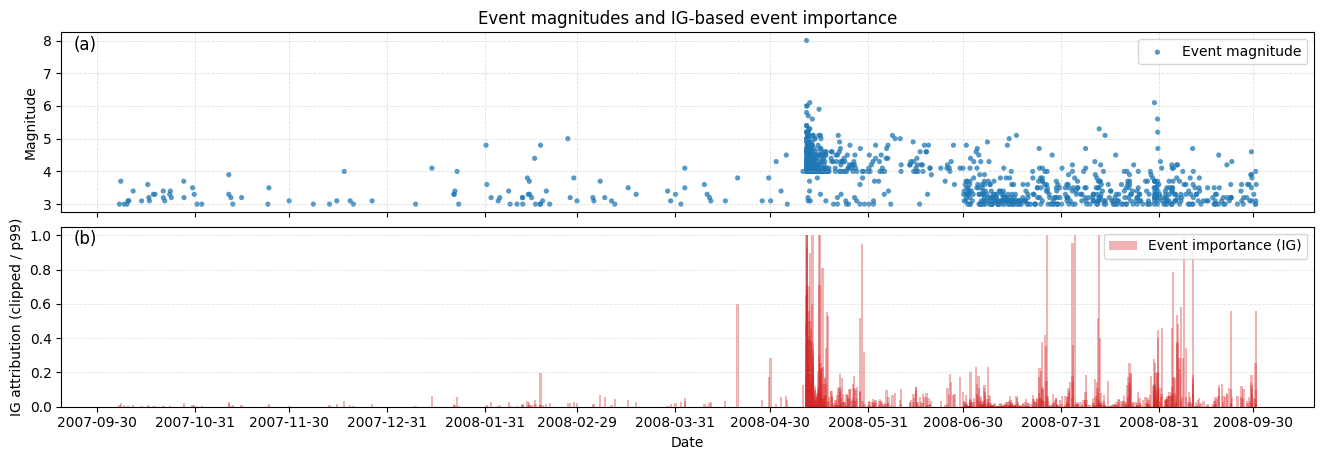

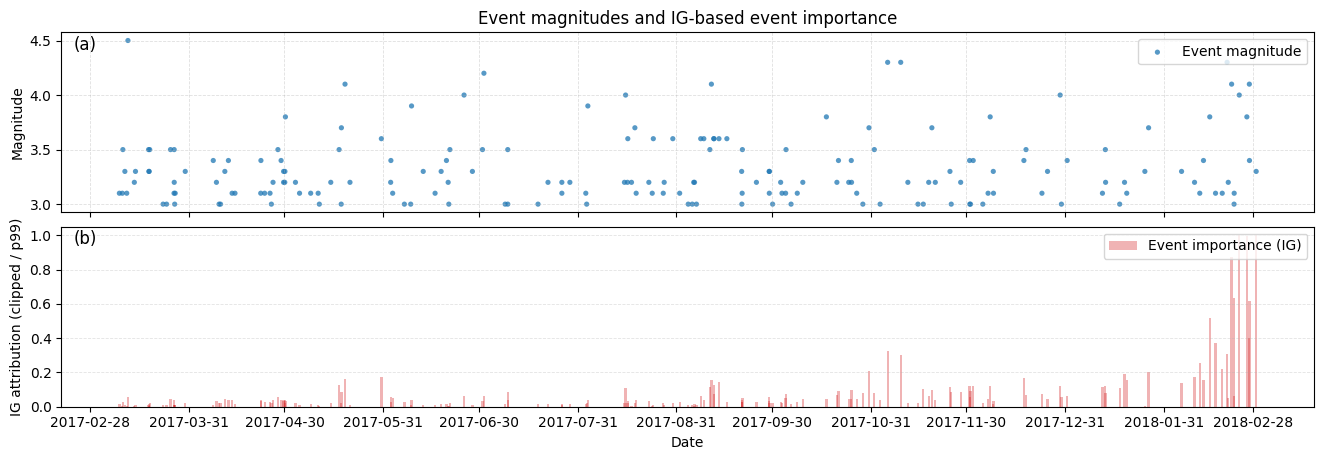

In [8]:
def batch_export_interpretability(
    model,
    data_loader,
    out_dir: Path,
    start_time,
    device: torch.device = DEVICE,
    every_n: int = 10,
    match_mod: int = 3,
    ig_steps: int = 200,
):
    out_dir.mkdir(parents=True, exist_ok=True)

    for batch_id, (x_batch, y_batch) in enumerate(data_loader):
        if batch_id % every_n != match_mod:
            continue

        x_batch = x_batch.to(device)
        sample_idx = np.random.randint(0, x_batch.shape[0])

        scores, _ = interp.compute_token_importance(
            model,
            x_batch,
            method='ig',
            n_steps=ig_steps,
            signed=False,
        )
        mask = get_non_pad_mask(x_batch[:, :, 0]).squeeze(-1).cpu().numpy().astype(bool)

        savepath = out_dir / f'reg_interp_{batch_id}_{sample_idx}.pdf'
        interp.plot_event_magnitude_and_importance_clean(
            x_batch,
            scores,
            batch_idx=sample_idx,
            time_channel=0,
            x_axis='time',
            start_time=start_time,
            time_scale=1.0,
            time_unit='D',
            mag_channel=2,
            importance_norm='p99',
            savepath=str(savepath),
            mag_color='tab:blue',
            imp_color='tab:red',
            mask=mask,
            height_ratios=(2, 2),
            xlabel='Date',
            clip_mag=None,
             panel_labels=('(a)', '(b)'),
        )


set_seed(0)
batch_export_interpretability(
    model=model,
    data_loader=data_loader,
    out_dir=FIG_BATCH_DIR,
    start_time=t0_np,
    every_n=10,
    match_mod=3,
    ig_steps=200,
)